In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [ ]:
data = pd.read_csv("C:\\Users\\bingi\\Downloads\\india_personal_loan_default_risk_2026.csv")
df = data.copy()
df.head()


,applicant_id,age,gender,marital_status,city_tier,state,employment_type,bank_account_vintage_years,monthly_income_inr,existing_loans_count,...,num_credit_inquiries_last_6m,late_payments_last_12m,loan_amount_requested_inr,loan_tenure_months,loan_purpose,collateral_provided,cibil_score,interest_rate_offered_pct,default_risk_score,default_flag
0,APP106868,22,Male,Single,Tier 3,Haryana,Salaried - PSU,0.5,12000,1,...,2.0,0,149000,48,Personal Expense,No,649,24.84,1.67,0
1,APP124016,35,Female,Divorced,Tier 2,Gujarat,Salaried - Private,0.5,32500,3,...,0.0,1,156000,60,Personal Expense,No,538,25.25,4.47,0
2,APP109668,41,Male,Married,Tier 2,Uttar Pradesh,Salaried - Government,2.8,52500,0,...,0.0,0,70000,36,Wedding,No,636,20.46,0.19,0
3,APP113640,29,Female,Married,Tier 2,Kerala,Salaried - PSU,0.7,15500,1,...,0.0,1,108000,48,Education,No,721,15.27,0.26,0
4,APP114018,31,Male,Married,Tier 1,Punjab,Self-Employed Professional,4.7,269600,2,...,0.0,2,466000,24,Education,No,586,25.52,2.10,0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   applicant_id                  25000 non-null  str    
 1   age                           25000 non-null  int64  
 2   gender                        25000 non-null  str    
 3   marital_status                25000 non-null  str    
 4   city_tier                     25000 non-null  str    
 5   state                         25000 non-null  str    
 6   employment_type               25000 non-null  str    
 7   bank_account_vintage_years    24625 non-null  float64
 8   monthly_income_inr            25000 non-null  int64  
 9   existing_loans_count          25000 non-null  int64  
 10  existing_emi_monthly_inr      24500 non-null  float64
 11  credit_utilization_ratio_pct  25000 non-null  float64
 12  num_credit_inquiries_last_6m  24750 non-null  float64
 13  late_payment

In [ ]:
df.describe()

,age,bank_account_vintage_years,monthly_income_inr,existing_loans_count,existing_emi_monthly_inr,credit_utilization_ratio_pct,num_credit_inquiries_last_6m,late_payments_last_12m,loan_amount_requested_inr,loan_tenure_months,cibil_score,interest_rate_offered_pct,default_risk_score,default_flag
count,25000.000000,24625.000000,25000.000000,25000.000000,24500.000000,25000.000000,24750.000000,25000.000000,2.500000e+04,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,35.303520,3.999647,54832.428000,1.103720,11705.636735,41.590360,1.298869,1.446680,1.584572e+05,42.401760,615.290640,20.714922,6.271094,0.061400
std,8.561309,3.900615,38347.488163,1.051421,10297.365558,19.804901,1.136458,1.271071,1.042315e+05,19.223168,63.057171,3.413218,11.938843,0.240067
min,21.000000,0.500000,12000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.500000e+04,12.000000,360.000000,10.570000,0.000000,0.000000
25%,29.000000,1.100000,29500.000000,0.000000,5100.000000,27.800000,0.000000,0.000000,8.800000e+04,24.000000,573.750000,18.810000,0.530000,0.000000
50%,35.000000,2.800000,45100.000000,1.000000,9000.000000,41.300000,1.000000,1.000000,1.330000e+05,36.000000,617.000000,21.050000,1.770000,0.000000
75%,41.000000,5.500000,68700.000000,2.000000,15100.000000,55.000000,2.000000,2.000000,1.990000e+05,60.000000,659.000000,23.510000,5.852500,0.000000
max,65.000000,25.000000,727000.000000,6.000000,202300.000000,100.000000,9.000000,8.000000,1.519000e+06,84.000000,866.000000,26.000000,99.080000,1.000000


In [ ]:
df.columns

Index(['applicant_id', 'age', 'gender', 'marital_status', 'city_tier', 'state',
       'employment_type', 'bank_account_vintage_years', 'monthly_income_inr',
       'existing_loans_count', 'existing_emi_monthly_inr',
       'credit_utilization_ratio_pct', 'num_credit_inquiries_last_6m',
       'late_payments_last_12m', 'loan_amount_requested_inr',
       'loan_tenure_months', 'loan_purpose', 'collateral_provided',
       'cibil_score', 'interest_rate_offered_pct', 'default_risk_score',
       'default_flag'],
      dtype='str')

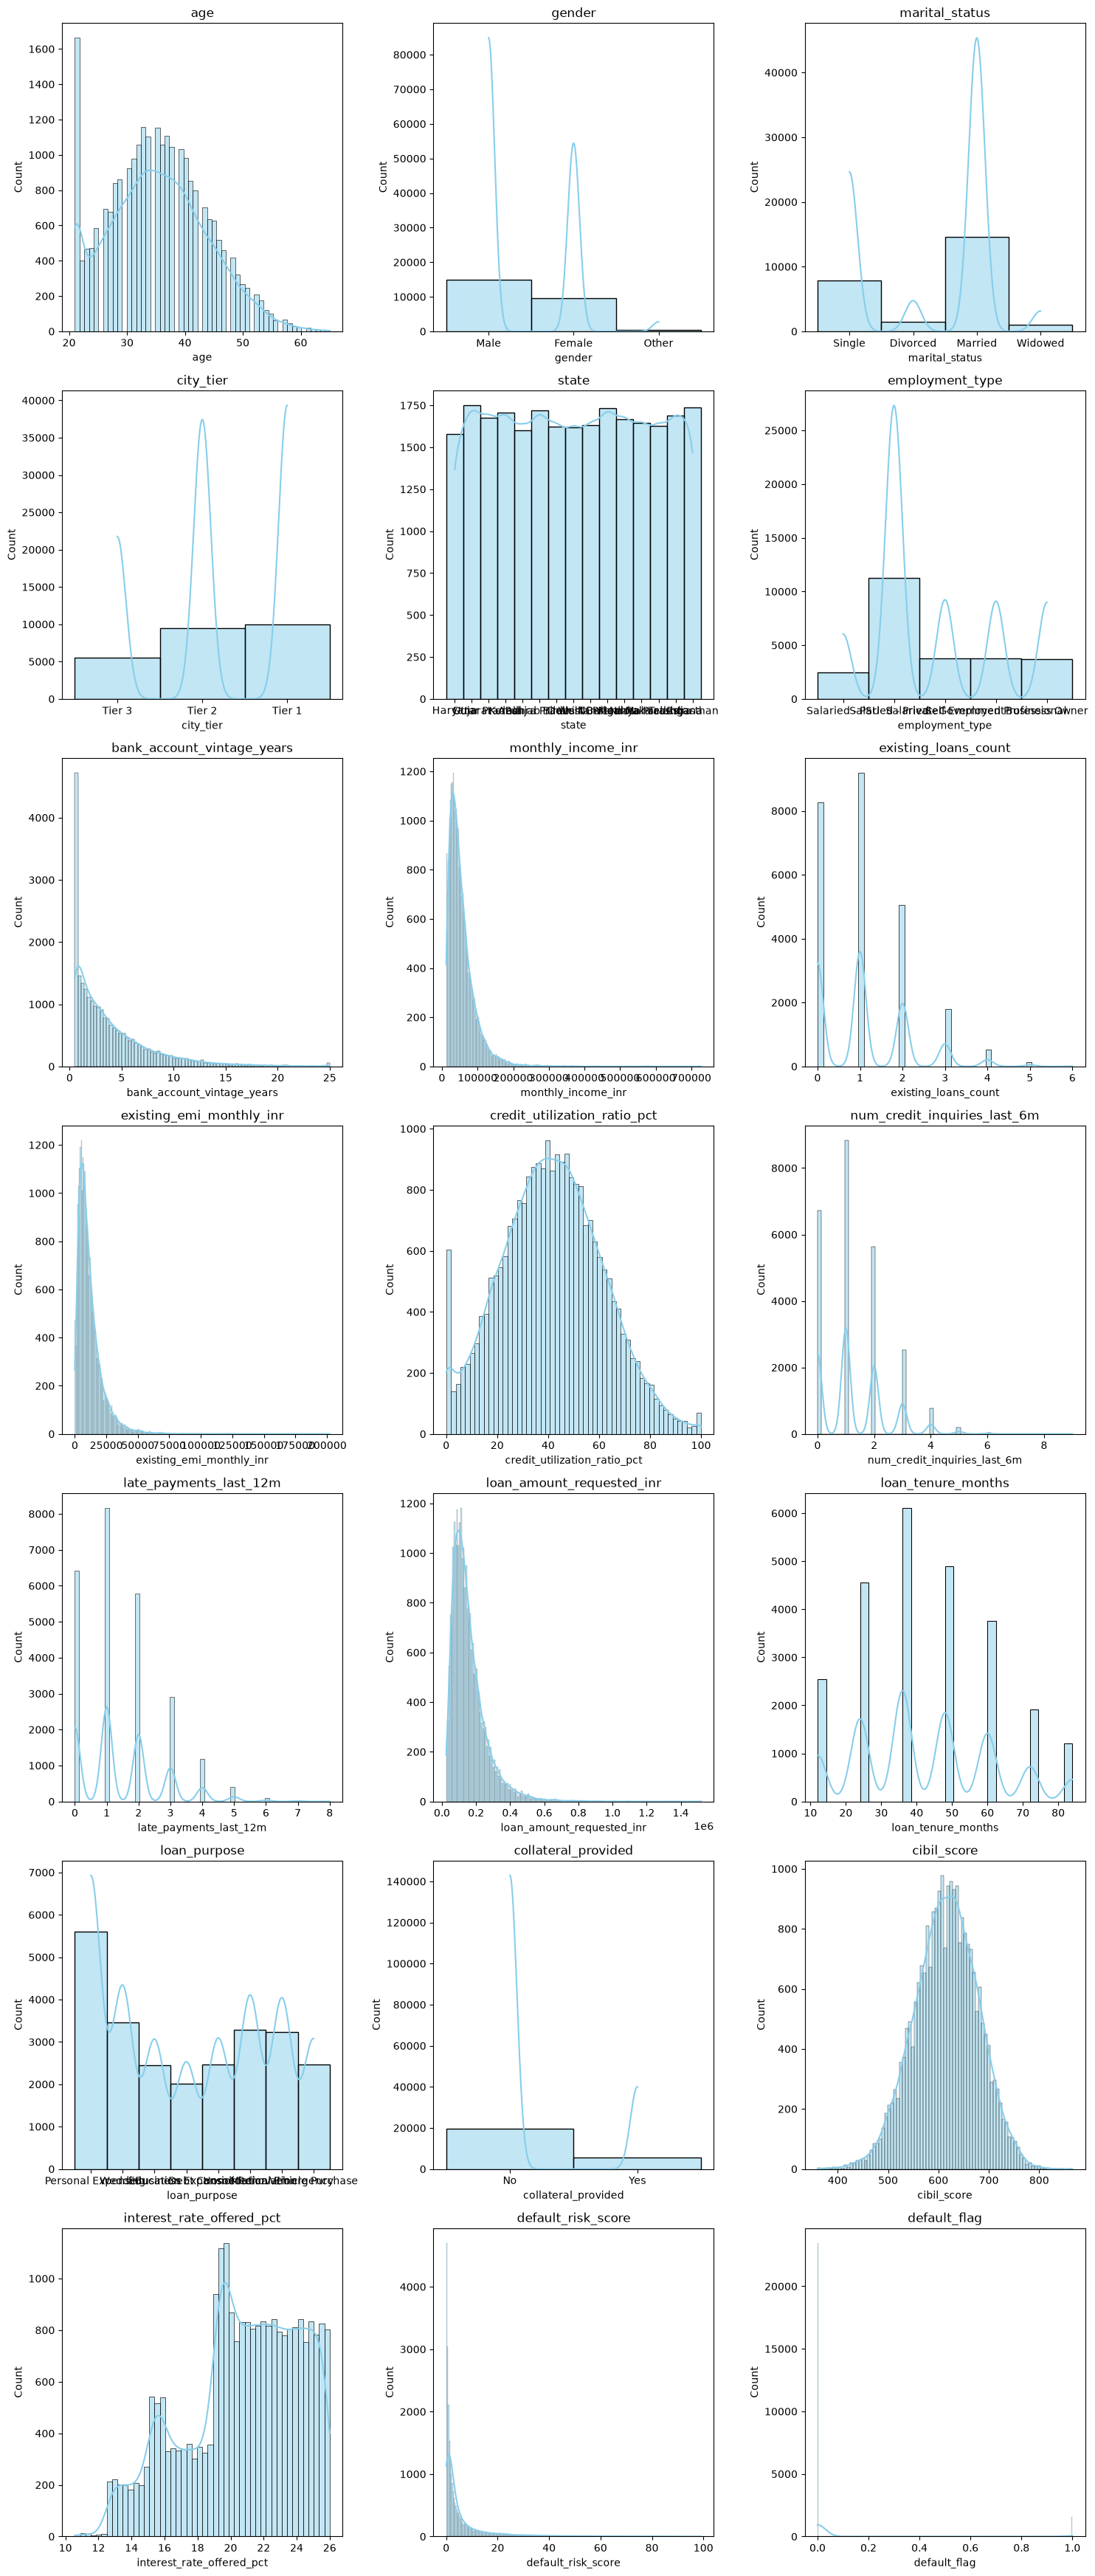

In [ ]:
cols = ['age', 'gender', 'marital_status', 'city_tier', 'state',
       'employment_type', 'bank_account_vintage_years', 'monthly_income_inr',
       'existing_loans_count', 'existing_emi_monthly_inr',
       'credit_utilization_ratio_pct', 'num_credit_inquiries_last_6m',
       'late_payments_last_12m', 'loan_amount_requested_inr',
       'loan_tenure_months', 'loan_purpose', 'collateral_provided',
       'cibil_score', 'interest_rate_offered_pct', 'default_risk_score',
       'default_flag']

import math
plt.figure(figsize=(15, 5*math.ceil(len(cols)/3)))

for i, col in enumerate(cols):
    plt.subplot(math.ceil(len(cols)/3), 3, i+1)
    
    if df[col].dtype == 'object':
        sns.countplot(data=df, x=col, hue=col, palette="Set2", legend=False)
    else:
        sns.histplot(data=df, x=col, color="skyblue", edgecolor="black", kde=True)
    
    plt.title(col, fontsize=12)

plt.tight_layout()
plt.show()

    

In [ ]:
for col in df.columns[2:]:  
    print(f"Column: {col}")
    print("Unique count:", df[col].nunique())
    print("Value counts:")
    print(df[col].value_counts())
    print("-"*50)


Column: gender
Unique count: 3
Value counts:
gender
Male      14928
Female     9587
Other       485
Name: count, dtype: int64
--------------------------------------------------
Column: marital_status
Unique count: 4
Value counts:
marital_status
Married     14558
Single       7907
Divorced     1525
Widowed      1010
Name: count, dtype: int64
--------------------------------------------------
Column: city_tier
Unique count: 3
Value counts:
city_tier
Tier 1    9978
Tier 2    9501
Tier 3    5521
Name: count, dtype: int64
--------------------------------------------------
Column: state
Unique count: 15
Value counts:
state
Gujarat           1750
Rajasthan         1737
Tamil Nadu        1731
Andhra Pradesh    1722
Kerala            1708
Telangana         1688
Uttar Pradesh     1674
Karnataka         1668
Madhya Pradesh    1643
West Bengal       1630
Maharashtra       1627
Bihar             1624
Delhi NCR         1619
Punjab            1600
Haryana           1579
Name: count, dtype: int64
----

In [ ]:
df.head()

,applicant_id,age,gender,marital_status,city_tier,state,employment_type,bank_account_vintage_years,monthly_income_inr,existing_loans_count,...,num_credit_inquiries_last_6m,late_payments_last_12m,loan_amount_requested_inr,loan_tenure_months,loan_purpose,collateral_provided,cibil_score,interest_rate_offered_pct,default_risk_score,default_flag
0,APP106868,22,Male,Single,Tier 3,Haryana,Salaried - PSU,0.5,12000,1,...,2.0,0,149000,48,Personal Expense,No,649,24.84,1.67,0
1,APP124016,35,Female,Divorced,Tier 2,Gujarat,Salaried - Private,0.5,32500,3,...,0.0,1,156000,60,Personal Expense,No,538,25.25,4.47,0
2,APP109668,41,Male,Married,Tier 2,Uttar Pradesh,Salaried - Government,2.8,52500,0,...,0.0,0,70000,36,Wedding,No,636,20.46,0.19,0
3,APP113640,29,Female,Married,Tier 2,Kerala,Salaried - PSU,0.7,15500,1,...,0.0,1,108000,48,Education,No,721,15.27,0.26,0
4,APP114018,31,Male,Married,Tier 1,Punjab,Self-Employed Professional,4.7,269600,2,...,0.0,2,466000,24,Education,No,586,25.52,2.10,0


In [ ]:
pivot = pd.pivot_table(
    df,
    index='state',          # rows
    columns='city_tier',    # columns
    aggfunc='size',         # count rows
    fill_value=0            # replace NaN with 0
)
print(pivot)


city_tier       Tier 1  Tier 2  Tier 3
state                                 
Andhra Pradesh     695     620     407
Bihar              660     617     347
Delhi NCR          659     623     337
Gujarat            687     667     396
Haryana            600     613     366
Karnataka          686     623     359
Kerala             701     623     384
Madhya Pradesh     671     616     356
Maharashtra        655     608     364
Punjab             657     593     350
Rajasthan          675     669     393
Tamil Nadu         690     675     366
Telangana          645     661     382
Uttar Pradesh      665     653     356
West Bengal        632     640     358


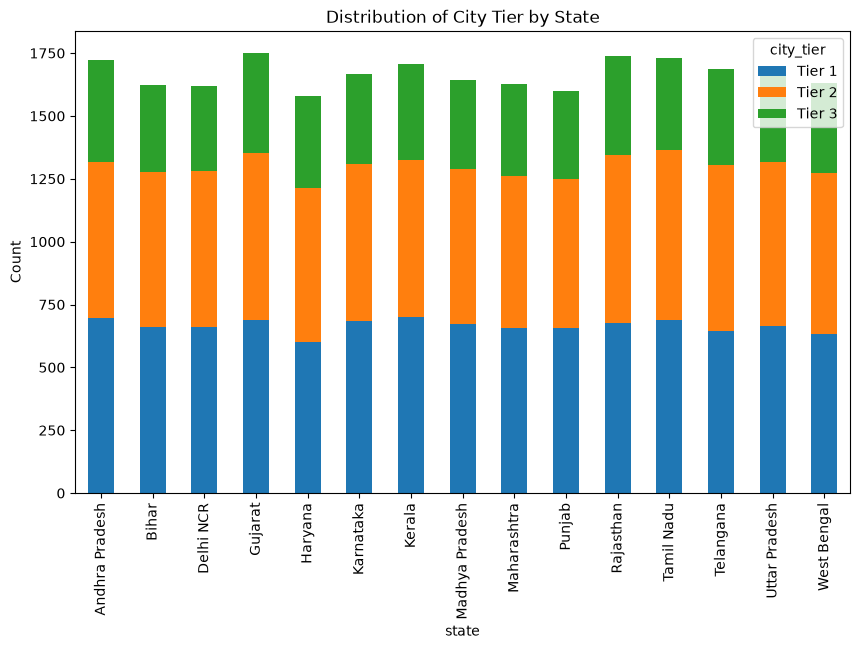

In [ ]:
pivot.plot(kind="bar", stacked=True, figsize=(10,6))
plt.title("Distribution of City Tier by State")
plt.ylabel("Count")
plt.show()


<Axes: xlabel='late_payments_last_12m', ylabel='cibil_score'>

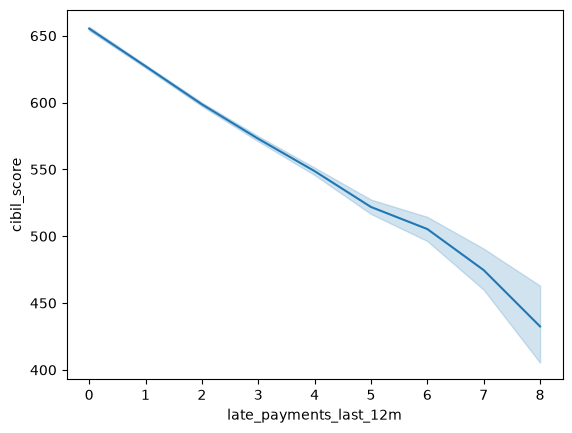

In [ ]:
sns.lineplot(data = df , x = 'late_payments_last_12m' , y = 'cibil_score')

C:\Users\bingi\AppData\Local\Temp\ipykernel_17752\3716566804.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


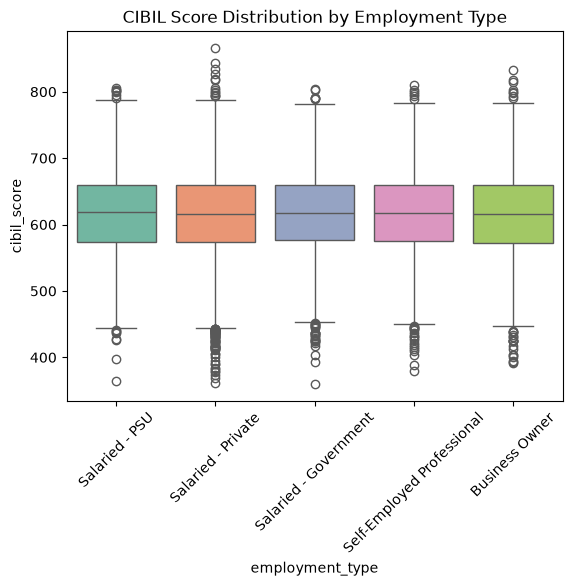

In [ ]:
sns.boxplot(
    data=df,
    x='employment_type',
    y='cibil_score',
    palette='Set2'
)
plt.xticks(rotation=45)
plt.title("CIBIL Score Distribution by Employment Type")
plt.show()



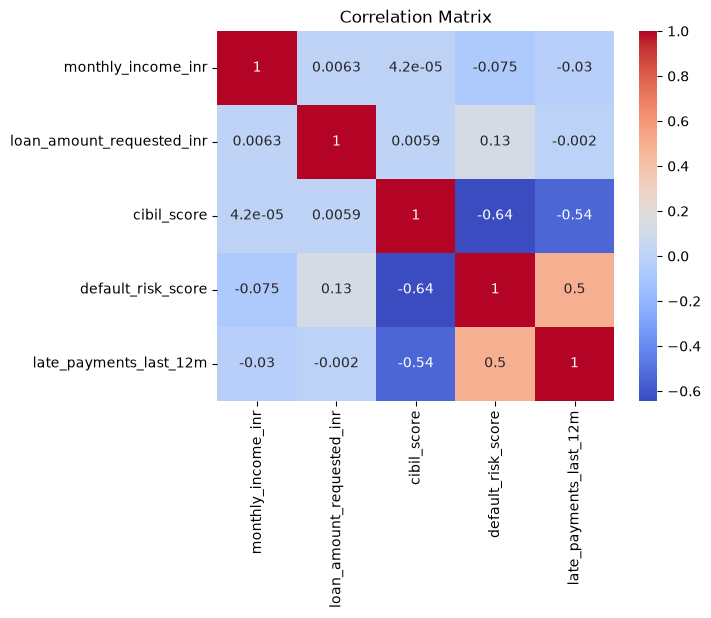

In [ ]:
corr = df[['monthly_income_inr','loan_amount_requested_inr',
           'cibil_score','default_risk_score','late_payments_last_12m']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()


In [ ]:
df.shape

(25000, 22)

In [ ]:
df.drop(columns='applicant_id' , inplace=True)

In [ ]:
y = df['default_flag']

X = df.drop('default_flag', axis=1)


In [ ]:
y.value_counts()

default_flag
0    23465
1     1535
Name: count, dtype: int64

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler , OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

num_col = X.select_dtypes(include='number').columns
cat_col = X.select_dtypes(exclude='number').columns

num_transformer = Pipeline(steps=[('imputer' , SimpleImputer(strategy='mean')),
                                  ('scaling' , StandardScaler())])

cat_transformer = Pipeline(steps = [('imputer' , SimpleImputer(strategy='most_frequent')),
                                    ('encoder' , OneHotEncoder(handle_unknown='ignore'))])

preprocessor = ColumnTransformer(transformers = [('numeric' , num_transformer , num_col),
                                                 ('category' , cat_transformer , cat_col)],
                                                remainder='drop')
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('category', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``featu

In [ ]:
from sklearn.model_selection import train_test_split

X_train , X_test , y_train , y_test = train_test_split(X , y ,test_size=0.2 ,stratify= y, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

models = {
    'Logistic Regression' : LogisticRegression(
        C = 1.0,
        solver = 'lbfgs',
        class_weight='balanced',
        max_iter=1000
    ),

    'decision tree' : DecisionTreeClassifier(
        max_depth = None,
        min_samples_leaf=2,
        min_samples_split=4,
        splitter='best',
        criterion='gini',
        class_weight='balanced',
        max_features='sqrt'
    ),

    'Support vector classifier' : SVC(
        C = 1.0,
        kernel = 'rbf',
        gamma = 'scale',
        class_weight='balanced',
        probability=True,
        max_iter=1000
    ),

    'Kneighbor' : KNeighborsClassifier(
        n_neighbors=5,
        weights = 'distance',
        metric = 'minkowski',
        p=2
    ),

    "RandomForestClassifier" : RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_leaf=2,
        min_samples_split=4,
        max_features='sqrt',
        bootstrap=True,
        class_weight = 'balanced'
    ),

    'XGBoost' : XGBClassifier(
        n_estimators = 100,
        learning_rate = 0.2,
        max_depth=5,            # maximum depth of each tree
        subsample=0.8,          # fraction of samples used per tree
        colsample_bytree=0.8,   # fraction of features used per tree
        gamma=0,                # minimum loss reduction for a split
        reg_alpha=0,            # L1 regularization
        reg_lambda=1,           # L2 regularization
        random_state=42,        # reproducibility
        use_label_encoder=False
    )
}

In [ ]:
from sklearn.metrics import accuracy_score , confusion_matrix , classification_report 
from sklearn.metrics import mean_squared_error , root_mean_squared_error , r2_score

results = {}

for name, model in models.items():
    print(f'Running model : {name}')   # show model name, not object
    
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'confusion matrix': confusion_matrix(y_test, y_pred),
        'classification report': classification_report(y_test, y_pred)
    }

# Print results neatly
for model_name, metrics in results.items():
    print(f"\nModel: {model_name}")
    print('Accuracy:', metrics['accuracy'])
    print('Confusion Matrix:\n', metrics['confusion matrix'])
    print('Classification Report:\n', metrics['classification report'])

Running model : Logistic Regression
Running model : decision tree
Running model : Support vector classifier


c:\Users\bingi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\bingi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:337: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\bingi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bingi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\metrics\_cl

Running model : Kneighbor
Running model : RandomForestClassifier
Running model : XGBoost


c:\Users\bingi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [03:08:17] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model: Logistic Regression
Accuracy: 0.8308
Confusion Matrix:
 [[3920  773]
 [  73  234]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.84      0.90      4693
           1       0.23      0.76      0.36       307

    accuracy                           0.83      5000
   macro avg       0.61      0.80      0.63      5000
weighted avg       0.94      0.83      0.87      5000


Model: decision tree
Accuracy: 0.9036
Confusion Matrix:
 [[4402  291]
 [ 191  116]]
Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.94      0.95      4693
           1       0.29      0.38      0.32       307

    accuracy                           0.90      5000
   macro avg       0.62      0.66      0.64      5000
weighted avg       0.92      0.90      0.91      5000


Model: Support vector classifier
Accuracy: 0.0614
Confusion Matrix:
 [[   0 4693]
 [   0  307]]
Classification Report:
  

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.pipeline import Pipeline

results = {}

for name, model in models.items():
    print(f'Running model : {name}')
    
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    
    # Predict on training data instead of test data
    y_pred_train = pipeline.predict(X_train)
    
    results[name] = {
        'accuracy': accuracy_score(y_train, y_pred_train),
        'confusion matrix': confusion_matrix(y_train, y_pred_train),
        'classification report': classification_report(y_train, y_pred_train)
    }

# Print results neatly
for model_name, metrics in results.items():
    print(f"\nModel: {model_name}")
    print('Accuracy:', metrics['accuracy'])
    print('Confusion Matrix:\n', metrics['confusion matrix'])
    print('Classification Report:\n', metrics['classification report'])


Running model : Logistic Regression
Running model : decision tree
Running model : Support vector classifier


c:\Users\bingi\PycharmProjects\JupyterProject2\.venv\Lib\site-packages\sklearn\svm\_base.py:313: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
c:\Users\bingi\PycharmProjects\JupyterProject2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bingi\PycharmProjects\JupyterProject2\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\bingi\PycharmProjects\JupyterProject2\.v

Running model : Kneighbor
Running model : RandomForestClassifier
Running model : XGBoost


c:\Users\bingi\PycharmProjects\JupyterProject2\.venv\Lib\site-packages\xgboost\training.py:200: UserWarning: [12:30:19] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Model: Logistic Regression
Accuracy: 0.8294
Confusion Matrix:
 [[15660  3112]
 [  300   928]]
Classification Report:
               precision    recall  f1-score   support

           0       0.98      0.83      0.90     18772
           1       0.23      0.76      0.35      1228

    accuracy                           0.83     20000
   macro avg       0.61      0.79      0.63     20000
weighted avg       0.94      0.83      0.87     20000


Model: decision tree
Accuracy: 0.9739
Confusion Matrix:
 [[18250   522]
 [    0  1228]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99     18772
           1       0.70      1.00      0.82      1228

    accuracy                           0.97     20000
   macro avg       0.85      0.99      0.91     20000
weighted avg       0.98      0.97      0.98     20000


Model: Support vector classifier
Accuracy: 0.0614
Confusion Matrix:
 [[    0 18772]
 [    0  1228]]
Classificatio

In [ ]:
train_acc = accuracy_score(y_train, pipeline.predict(X_train))
test_acc  = accuracy_score(y_test, pipeline.predict(X_test))
print(f"{name} → Train: {train_acc:.3f}, Test: {test_acc:.3f}")


XGBoost → Train: 0.964, Test: 0.943


In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
import pandas as pd

results = {}

for name, model in models.items():
    print(f'Running model : {name}')
    
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    
    # Predictions on train and test
    y_pred_train = pipeline.predict(X_train)
    y_pred_test  = pipeline.predict(X_test)
    
    train_acc = accuracy_score(y_train, y_pred_train)
    test_acc  = accuracy_score(y_test, y_pred_test)
    
    results[name] = {
        'Train Accuracy': train_acc,
        'Test Accuracy': test_acc,
        'Generalization Gap': train_acc - test_acc
    }

# Summarize neatly in a DataFrame
results_df = pd.DataFrame(results).T
print("\nTrain vs Test Accuracy Comparison:\n")
print(results_df)


Running model : Logistic Regression
Running model : decision tree
Running model : Support vector classifier


c:\Users\bingi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\bingi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:337: ConvergenceWarning: Solver terminated early (max_iter=1000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(


Running model : Kneighbor
Running model : RandomForestClassifier
Running model : XGBoost


c:\Users\bingi\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\xgboost\training.py:200: UserWarning: [03:09:13] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:794: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Train vs Test Accuracy Comparison:

                           Train Accuracy  Test Accuracy  Generalization Gap
Logistic Regression               0.82940         0.8308            -0.00140
decision tree                     0.97425         0.8972             0.07705
Support vector classifier         0.06140         0.0614             0.00000
Kneighbor                         1.00000         0.9414             0.05860
RandomForestClassifier            0.98730         0.9296             0.05770
XGBoost                           0.96360         0.9432             0.02040


In [ ]:
from sklearn.cluster import KMeans

X_preprocessed = preprocessor.fit_transform(X)

kmeans = KMeans(n_clusters=3 , init = 'k-means++')
cluster = kmeans.fit(X_preprocessed)

In [ ]:
df['cluster'] = kmeans.labels_
df.head()

,age,gender,marital_status,city_tier,state,employment_type,bank_account_vintage_years,monthly_income_inr,existing_loans_count,existing_emi_monthly_inr,...,late_payments_last_12m,loan_amount_requested_inr,loan_tenure_months,loan_purpose,collateral_provided,cibil_score,interest_rate_offered_pct,default_risk_score,default_flag,cluster
0,22,Male,Single,Tier 3,Haryana,Salaried - PSU,0.5,12000,1,1700.0,...,0,149000,48,Personal Expense,No,649,24.84,1.67,0,1
1,35,Female,Divorced,Tier 2,Gujarat,Salaried - Private,0.5,32500,3,11500.0,...,1,156000,60,Personal Expense,No,538,25.25,4.47,0,1
2,41,Male,Married,Tier 2,Uttar Pradesh,Salaried - Government,2.8,52500,0,6000.0,...,0,70000,36,Wedding,No,636,20.46,0.19,0,1
3,29,Female,Married,Tier 2,Kerala,Salaried - PSU,0.7,15500,1,1900.0,...,1,108000,48,Education,No,721,15.27,0.26,0,0
4,31,Male,Married,Tier 1,Punjab,Self-Employed Professional,4.7,269600,2,50800.0,...,2,466000,24,Education,No,586,25.52,2.10,0,1


In [ ]:
df['cluster'].value_counts()

cluster
1    14125
0     7900
2     2975
Name: count, dtype: int64

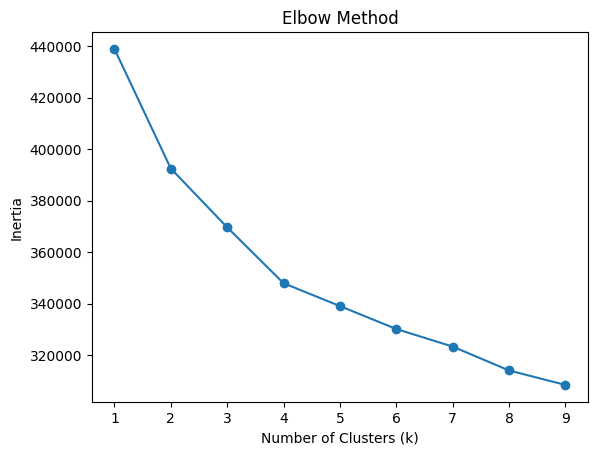

In [ ]:
inertia = []

for k in range(1,10):
    km = KMeans(n_clusters=k , init='k-means++' , random_state=42)
    km.fit(X_preprocessed)
    inertia.append(km.inertia_)

plt.plot(range(1,10), inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

<Axes: xlabel='cibil_score', ylabel='default_risk_score'>

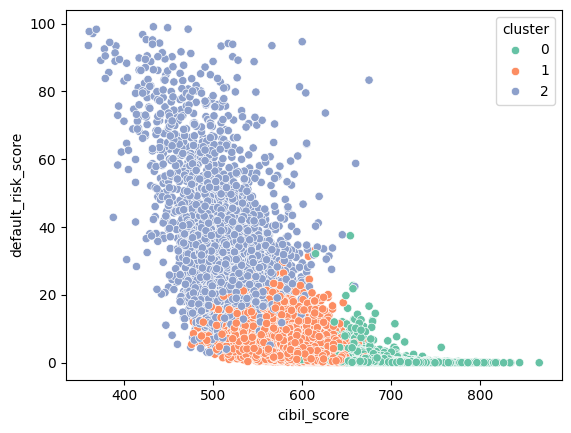

In [ ]:
sns.scatterplot(data=df , x = 'cibil_score' , y = 'default_risk_score' , hue = 'cluster' , palette='Set2')

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_score = silhouette_score(X_preprocessed ,kmeans.labels_)
silhouette_score

0.08874554771263307

In [ ]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score
import numpy as np

sample_size = min(1000, X.shape[0])
sample_idx = np.random.choice(X.shape[0], sample_size, replace=False)
X_sample = X_preprocessed[sample_idx]   # ✅ use transformed sample

silhouette_scores = {}
inertia = {}
K = range(2, 10)

for k in K:
    kmeans = MiniBatchKMeans(n_clusters=k, init='k-means++', batch_size=10000, random_state=42)
    labels = kmeans.fit_predict(X_preprocessed)

    inertia[k] = kmeans.inertia_
    score = silhouette_score(X_sample, labels[sample_idx])
    silhouette_scores[k] = score

    print(f"k={k}, inertia={kmeans.inertia_:.0f}, silhouette score={score:.3f}")


k=2, inertia=394286, silhouette score=0.103
k=3, inertia=374162, silhouette score=0.070
k=4, inertia=362898, silhouette score=0.061
k=5, inertia=353529, silhouette score=0.063
k=6, inertia=333346, silhouette score=0.074
k=7, inertia=324444, silhouette score=0.057
k=8, inertia=320356, silhouette score=0.048
k=9, inertia=318023, silhouette score=0.042


k=2, inertia=229107, silhouette score=0.152
k=3, inertia=206058, silhouette score=0.149
k=4, inertia=185530, silhouette score=0.158
k=5, inertia=175690, silhouette score=0.128
k=6, inertia=167546, silhouette score=0.131
k=7, inertia=160000, silhouette score=0.129
k=8, inertia=155844, silhouette score=0.107
k=9, inertia=151342, silhouette score=0.108


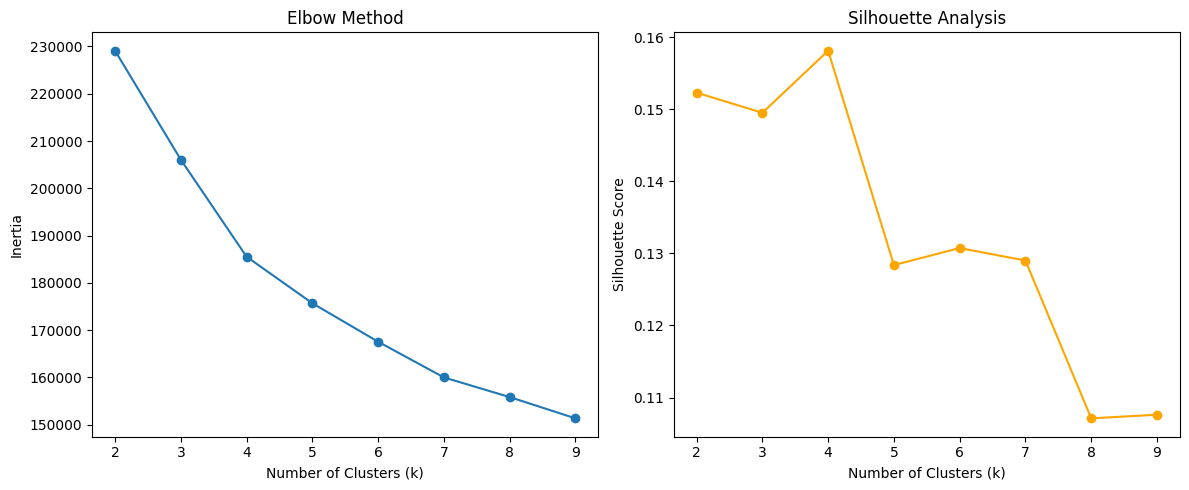

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import silhouette_score

# --- Step 1: Select Financial Columns ---
financial_cols = [
    'monthly_income_inr',
    'existing_loans_count',
    'existing_emi_monthly_inr',
    'credit_utilization_ratio_pct',
    'num_credit_inquiries_last_6m',
    'late_payments_last_12m',
    'loan_amount_requested_inr',
    'loan_tenure_months',
    'cibil_score',
    'interest_rate_offered_pct',
    'default_risk_score'
]

X_financial = X[financial_cols]

# --- Step 2: Preprocess (Impute + Scale) ---
pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

X_financial_preprocessed = pipeline.fit_transform(X_financial)

# --- Step 3: Clustering + Evaluation ---
inertia = []
silhouette_scores = []
K = range(2, 10)

for k in K:
    km = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = km.fit_predict(X_financial_preprocessed)
    inertia.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_financial_preprocessed, labels))
    print(f"k={k}, inertia={km.inertia_:.0f}, silhouette score={silhouette_scores[-1]:.3f}")

# --- Step 4: Plot Results ---
plt.figure(figsize=(12,5))

# Elbow Method
plt.subplot(1,2,1)
plt.plot(K, inertia, marker='o')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

# Silhouette Scores
plt.subplot(1,2,2)
plt.plot(K, silhouette_scores, marker='o', color='orange')
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.tight_layout()
plt.show()

# --- Step 5: Attach Cluster Labels to Data ---
best_k = 3  # or choose based on elbow/silhouette
final_kmeans = KMeans(n_clusters=best_k, init='k-means++', random_state=42)
X['cluster_financial'] = final_kmeans.fit_predict(X_financial_preprocessed)


In [ ]:
# Select financial columns + cluster labels
financial_cols = [
    'monthly_income_inr',
    'existing_loans_count',
    'existing_emi_monthly_inr',
    'credit_utilization_ratio_pct',
    'num_credit_inquiries_last_6m',
    'late_payments_last_12m',
    'loan_amount_requested_inr',
    'loan_tenure_months',
    'cibil_score',
    'interest_rate_offered_pct',
    'default_risk_score'
]

# Group by cluster and compute averages
cluster_profile = X.groupby('cluster_financial')[financial_cols].mean().round(2)

print(cluster_profile)


                   monthly_income_inr  existing_loans_count  \
cluster_financial                                             
0                            50553.11                  1.64   
1                            52896.46                  0.85   
2                            56825.13                  1.13   

                   existing_emi_monthly_inr  credit_utilization_ratio_pct  \
cluster_financial                                                           
0                                  14000.31                         62.23   
1                                   9270.41                         25.88   
2                                  12592.43                         46.08   

                   num_credit_inquiries_last_6m  late_payments_last_12m  \
cluster_financial                                                         
0                                          1.58                     3.2   
1                                          1.16                     0.7  